✓ Reproducibility block applied (SEED=42) | Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ STAGE_DIR : /content/drive/MyDrive/NLP FINAL/rq6_transformer
✓ SAVE_DIR  : /content/drive/MyDrive/NLP FINAL/rq6_transformer/models/distilbert_phishguard
Train/Val/Test : 13,041 / 2,795 / 2,795
Class weights  : Legitimate=0.8228, Phishing=1.2745


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

✓ save_pretrained() → /content/drive/MyDrive/NLP FINAL/rq6_transformer/models/distilbert_phishguard/
  config.json | model.safetensors | tokenizer files
✓ Saved training_history.csv


,model_name,epoch,train_loss,learning_rate,val_loss,val_accuracy,val_macro_f1,val_phishing_recall,val_roc_auc,val_pr_auc
0,DistilBERT,1,0.1817,1.482524e-05,0.0883,0.9732,0.9719,0.9654,0.9969,0.9952
1,DistilBERT,2,0.0506,7.417158e-06,0.0631,0.9800,0.9791,0.9845,0.9982,0.9970
2,DistilBERT,3,0.0285,9.078529e-09,0.0697,0.9792,0.9783,0.9809,0.9981,0.9970



Evaluating on TEST set...


  Accuracy       : 0.9753
  Macro-F1       : 0.9742
  ROC-AUC        : 0.9974
  PR-AUC         : 0.9952
  Phishing Recall: 0.9818
✓ Saved all results CSVs

Generating diagrams...


/tmp/ipykernel_1069/628671042.py:352: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc":        datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),


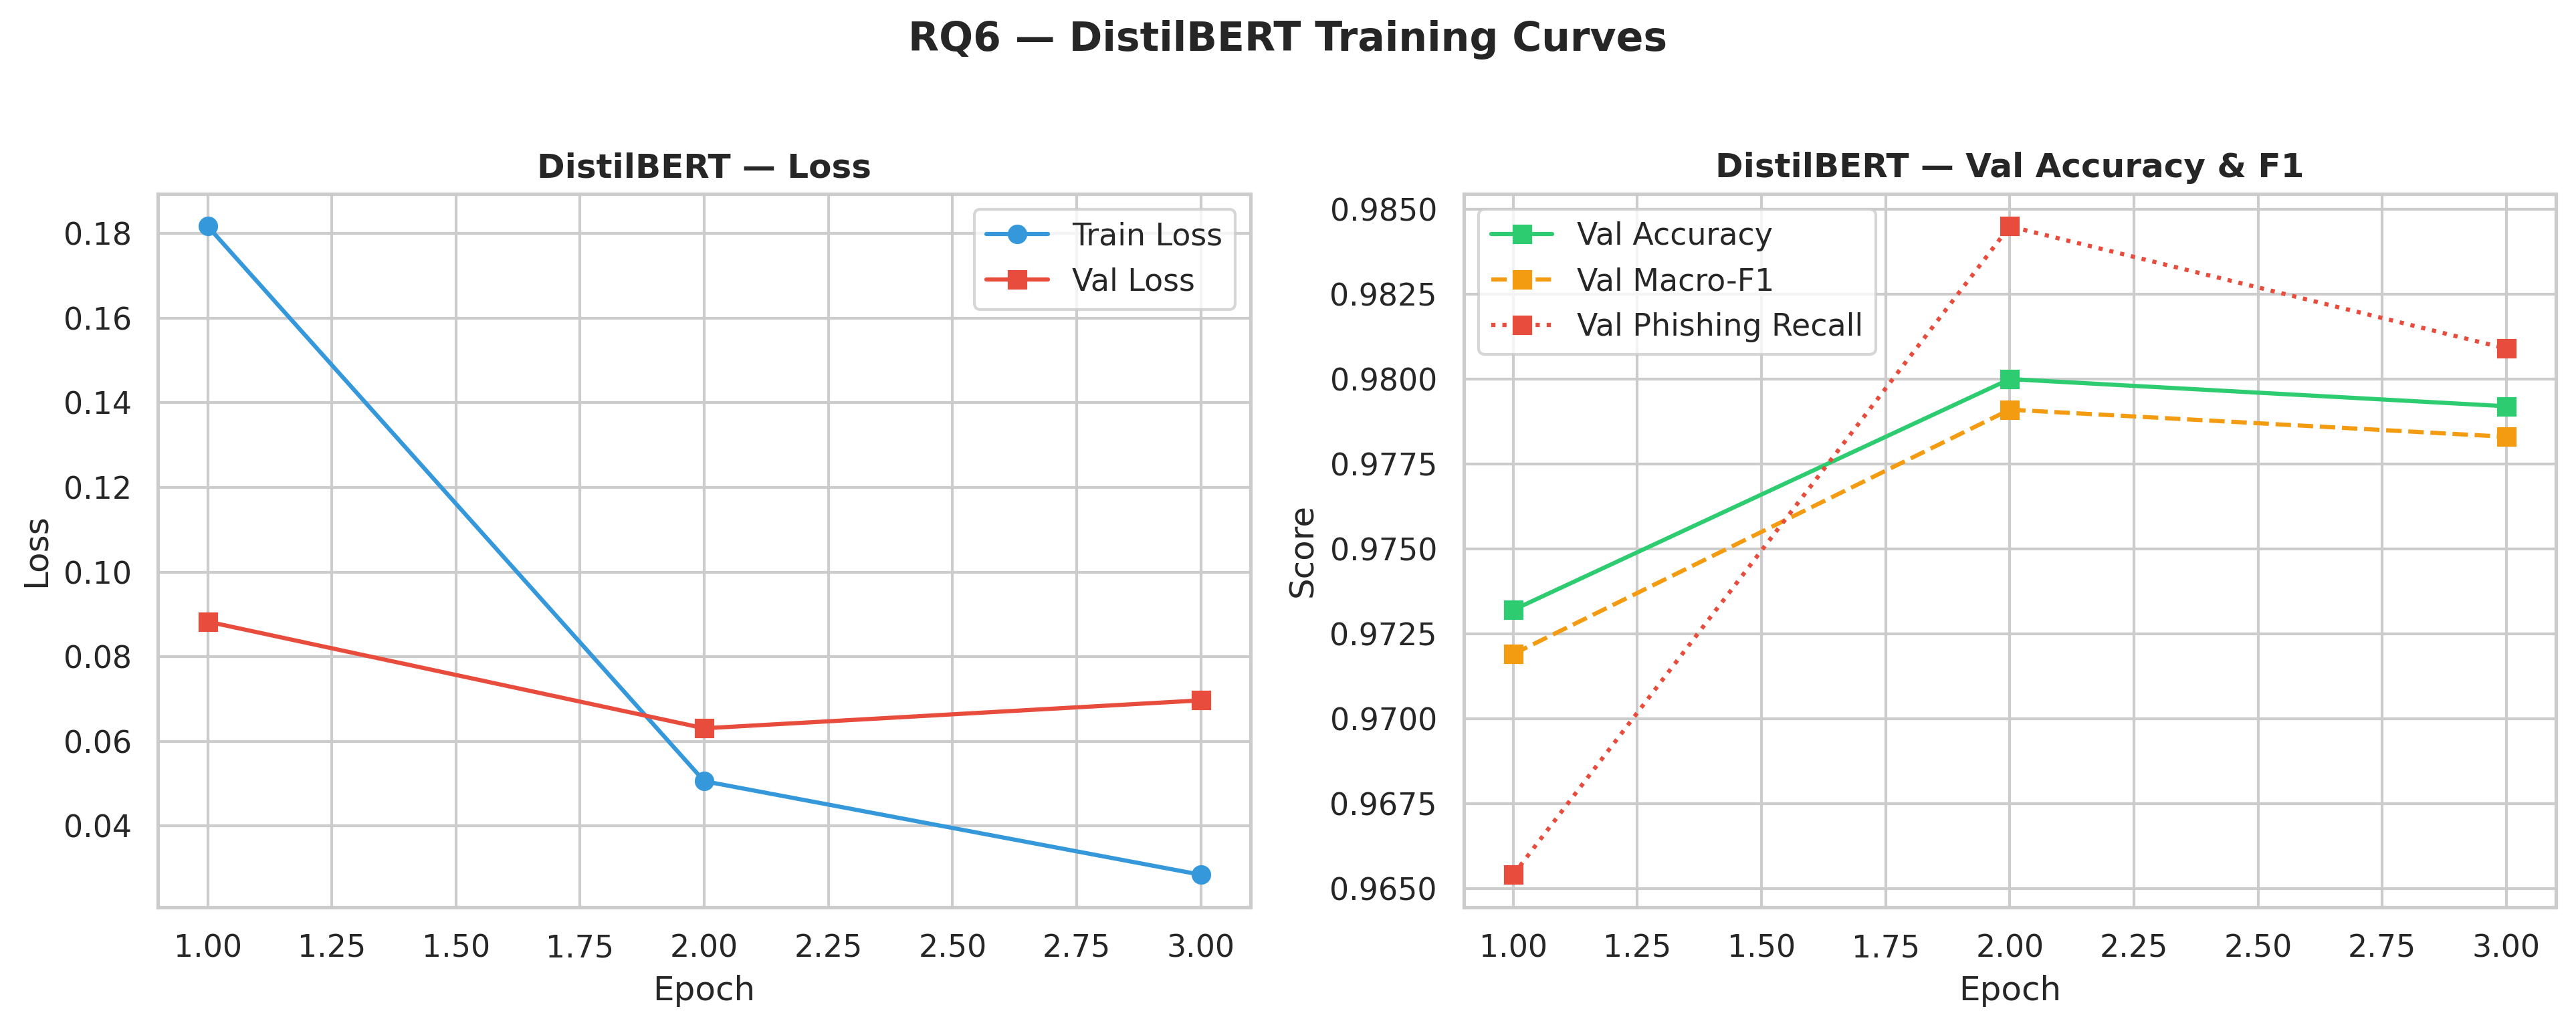

  ✓ rq6_distilbert_training_curves.png
  ✓ rq6_cm_distilbert_raw.png
  ✓ rq6_cm_distilbert_normalized.png

RQ6 — DISTILBERT TRANSFORMER COMPLETE ✓

Model saved → /content/drive/MyDrive/NLP FINAL/rq6_transformer/models/distilbert_phishguard/
  (config.json + model.safetensors + tokenizer)

Logs   → /content/drive/MyDrive/NLP FINAL/rq6_transformer/logs/training_history.csv

Results → /content/drive/MyDrive/NLP FINAL/rq6_transformer/results/

── Test Set Performance ──


,Model,Family,Accuracy,Precision,Recall,Macro-F1,ROC-AUC,PR-AUC,Phishing Recall,Best Val F1
0,DistilBERT,Transformer,0.9753,0.9564,0.9818,0.9742,0.9974,0.9952,0.9818,0.9791



✓ 8 models / 6 families now complete:
  NB | LogReg | SVM | RF | XGBoost | BiLSTM | TextCNN | DistilBERT

Next step → RQ7 (Hyperparameter Tuning: SVM, RF, LogReg)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PhishGuard AI — RQ6: Transformer Model (DistilBERT fine-tuning)
# Input : train/val/test.csv (text_cleaned_transformer)
# Output: save_pretrained model + metrics + diagrams
# ═══════════════════════════════════════════════════════════════════════════════

# ═══ CELL 1 — Reproducibility Block ═══
import os, random, numpy as np, torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Reproducibility block applied (SEED=42) | Device: {DEVICE}")
if DEVICE.type == "cpu":
    print("⚠ Enable GPU (Runtime → T4 GPU) — DistilBERT fine-tuning is very slow on CPU")


# ═══ CELL 2 — Drive mount + folder tree ═══
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR    = "/content/drive/MyDrive/NLP FINAL"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
STAGE_DIR   = os.path.join(BASE_DIR, "rq6_transformer")

MODELS_DIR   = os.path.join(STAGE_DIR, "models")
LOGS_DIR     = os.path.join(STAGE_DIR, "logs")
RESULTS_DIR  = os.path.join(STAGE_DIR, "results")
DIAGRAMS_DIR = os.path.join(STAGE_DIR, "diagrams")
CKPT_DIR     = os.path.join(MODELS_DIR, "checkpoints")
SAVE_DIR     = os.path.join(MODELS_DIR, "distilbert_phishguard")

for folder in [MODELS_DIR, LOGS_DIR, RESULTS_DIR, DIAGRAMS_DIR, CKPT_DIR, SAVE_DIR]:
    os.makedirs(folder, exist_ok=True)

TRAIN_PATH = os.path.join(DATASET_DIR, "train.csv")
VAL_PATH   = os.path.join(DATASET_DIR, "val.csv")
TEST_PATH  = os.path.join(DATASET_DIR, "test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing: {p}\nRun Stage 0 first.")

print(f"✓ STAGE_DIR : {STAGE_DIR}")
print(f"✓ SAVE_DIR  : {SAVE_DIR}")


# ═══ CELL 3 — Install + imports ═══
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "transformers", "accelerate", "scikit-learn",
                       "matplotlib", "seaborn", "pandas"])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from datetime import datetime
from scipy.special import softmax
from torch.utils.data import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report,
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback,
)

DPI = 300
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = DPI
plt.rcParams["savefig.dpi"] = DPI


# ═══ CELL 4 — Hyperparameters ═══
PRETRAINED_MODEL = "distilbert-base-uncased"
NUM_EPOCHS       = 3          # plan: 2–3 epochs
MAX_LEN          = 512        # BERT standard max length
BATCH_SIZE       = 16         # reduce to 8 if CUDA OOM
LEARNING_RATE    = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1


# ═══ CELL 5 — Load data ═══
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

train_texts = train_df["text_cleaned_transformer"].astype(str).tolist()
val_texts   = val_df["text_cleaned_transformer"].astype(str).tolist()
test_texts  = test_df["text_cleaned_transformer"].astype(str).tolist()

y_train = train_df["label"].values.astype(int)
y_val   = val_df["label"].values.astype(int)
y_test  = test_df["label"].values.astype(int)

# Balanced class weights for CrossEntropyLoss
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1]), y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print(f"Train/Val/Test : {len(y_train):,} / {len(y_val):,} / {len(y_test):,}")
print(f"Class weights  : Legitimate={class_weights[0]:.4f}, Phishing={class_weights[1]:.4f}")


# ═══ CELL 6 — Tokenizer + PyTorch Dataset ═══
tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)

class PhishingEmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts   = texts
        self.labels  = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = PhishingEmailDataset(train_texts, y_train, tokenizer, MAX_LEN)
val_dataset   = PhishingEmailDataset(val_texts,   y_val,   tokenizer, MAX_LEN)
test_dataset  = PhishingEmailDataset(test_texts,  y_test,  tokenizer, MAX_LEN)

print(f"✓ Tokenizer loaded: {PRETRAINED_MODEL}  |  max_length={MAX_LEN}")


# ═══ CELL 7 — Model + weighted Trainer ═══
model = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL, num_labels=2
)


class WeightedTrainer(Trainer):
    """CrossEntropyLoss with balanced class weights (imbalance handling)."""
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        weight = self.class_weights.to(outputs.logits.device) if self.class_weights is not None else None
        loss = torch.nn.functional.cross_entropy(outputs.logits, labels, weight=weight)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = softmax(logits, axis=-1)[:, 1]
    return {
        "accuracy":        accuracy_score(labels, preds),
        "macro_f1":        f1_score(labels, preds, average="macro", zero_division=0),
        "phishing_recall": recall_score(labels, preds, pos_label=1, zero_division=0),
        "roc_auc":         roc_auc_score(labels, probs),
        "pr_auc":          average_precision_score(labels, probs),
    }


training_args = TrainingArguments(
    output_dir                  = CKPT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    greater_is_better           = True,
    logging_strategy            = "epoch",
    save_total_limit            = 2,
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
    report_to                   = "none",
    dataloader_num_workers      = 0,
)

trainer = WeightedTrainer(
    class_weights     = class_weights_tensor,
    model             = model,
    args              = training_args,
    train_dataset     = train_dataset,
    eval_dataset      = val_dataset,
    compute_metrics   = compute_metrics,
    callbacks         = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("✓ DistilBERT model + WeightedTrainer ready")


# ═══ CELL 8 — Fine-tune ═══
print(f"\nFine-tuning DistilBERT for {NUM_EPOCHS} epochs...\n")
trainer.train()
print("\n✓ Fine-tuning complete")


# ═══ CELL 9 — Save model + tokenizer (save_pretrained) ═══
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"✓ save_pretrained() → {SAVE_DIR}/")
print("  config.json | model.safetensors | tokenizer files")


# ═══ CELL 10 — Build training_history.csv from Trainer logs ═══
log_history = trainer.state.log_history

history_rows = []
epoch_train, epoch_eval = {}, {}

for entry in log_history:
    if "epoch" not in entry:
        continue
    ep = round(entry["epoch"])
    if "loss" in entry and "eval_loss" not in entry:
        epoch_train[ep] = {"train_loss": round(entry["loss"], 4)}
        if "learning_rate" in entry:
            epoch_train[ep]["learning_rate"] = entry["learning_rate"]
    if "eval_loss" in entry:
        epoch_eval[ep] = {
            "val_loss":           round(entry["eval_loss"], 4),
            "val_accuracy":       round(entry.get("eval_accuracy", 0), 4),
            "val_macro_f1":       round(entry.get("eval_macro_f1", 0), 4),
            "val_phishing_recall": round(entry.get("eval_phishing_recall", 0), 4),
            "val_roc_auc":        round(entry.get("eval_roc_auc", 0), 4),
            "val_pr_auc":         round(entry.get("eval_pr_auc", 0), 4),
        }

for ep in sorted(set(list(epoch_train.keys()) + list(epoch_eval.keys()))):
    row = {"model_name": "DistilBERT", "epoch": ep}
    row.update(epoch_train.get(ep, {}))
    row.update(epoch_eval.get(ep, {}))
    history_rows.append(row)

history_df = pd.DataFrame(history_rows)
history_df.to_csv(os.path.join(LOGS_DIR, "training_history.csv"), index=False)
print("✓ Saved training_history.csv")
display(history_df)


# ═══ CELL 11 — Evaluate on TEST set ═══
print("\nEvaluating on TEST set...")
predictions = trainer.predict(test_dataset)
logits      = predictions.predictions
y_pred      = np.argmax(logits, axis=-1)
y_prob      = softmax(logits, axis=-1)[:, 1]

test_metrics = {
    "accuracy":        round(accuracy_score(y_test, y_pred), 4),
    "precision":       round(precision_score(y_test, y_pred, zero_division=0), 4),
    "recall":          round(recall_score(y_test, y_pred, zero_division=0), 4),
    "macro_f1":        round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
    "roc_auc":         round(roc_auc_score(y_test, y_prob), 4),
    "pr_auc":          round(average_precision_score(y_test, y_prob), 4),
    "phishing_recall": round(recall_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
}

best_val_f1 = round(max(history_df["val_macro_f1"]) if "val_macro_f1" in history_df.columns and len(history_df) else 0, 4)

print(f"  Accuracy       : {test_metrics['accuracy']}")
print(f"  Macro-F1       : {test_metrics['macro_f1']}")
print(f"  ROC-AUC        : {test_metrics['roc_auc']}")
print(f"  PR-AUC         : {test_metrics['pr_auc']}")
print(f"  Phishing Recall: {test_metrics['phishing_recall']}")


# ═══ CELL 12 — Save results CSVs ═══
overall_metrics_df = pd.DataFrame([{
    "model_key":    "distilbert",
    "model_name":   "DistilBERT",
    "model_family": "Transformer",
    "eval_set":     "test",
    "best_val_f1":  best_val_f1,
    **test_metrics,
}])
overall_metrics_df.to_csv(os.path.join(RESULTS_DIR, "overall_metrics.csv"), index=False)

report = classification_report(
    y_test, y_pred, target_names=["Legitimate", "Phishing"],
    output_dict=True, zero_division=0,
)
classification_rows = []
for lbl in ["Legitimate", "Phishing", "macro avg"]:
    classification_rows.append({
        "model_key": "distilbert", "model_name": "DistilBERT", "class": lbl,
        "precision": round(report[lbl]["precision"], 4),
        "recall":    round(report[lbl]["recall"], 4),
        "f1_score":  round(report[lbl]["f1-score"], 4),
        "support":   int(report[lbl]["support"]),
    })
pd.DataFrame(classification_rows).to_csv(
    os.path.join(RESULTS_DIR, "classification_report.csv"), index=False)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
pd.DataFrame([{
    "model_key": "distilbert", "model_name": "DistilBERT",
    "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    "phishing_recall": test_metrics["phishing_recall"],
}]).to_csv(os.path.join(RESULTS_DIR, "confusion_matrix.csv"), index=False)

pd.DataFrame({
    "y_true": y_test,
    "distilbert_y_pred": y_pred,
    "distilbert_phishing_prob": np.round(y_prob, 6),
}).to_csv(os.path.join(RESULTS_DIR, "test_predictions.csv"), index=False)

paper_table = overall_metrics_df[[
    "model_name", "model_family", "accuracy", "precision", "recall",
    "macro_f1", "roc_auc", "pr_auc", "phishing_recall", "best_val_f1",
]].copy()
paper_table.columns = [
    "Model", "Family", "Accuracy", "Precision", "Recall",
    "Macro-F1", "ROC-AUC", "PR-AUC", "Phishing Recall", "Best Val F1",
]
paper_table.to_csv(os.path.join(RESULTS_DIR, "paper_table_rq6_transformer.csv"), index=False)

config = {
    "project":              "PhishGuard AI",
    "stage":                "RQ6 — DistilBERT Transformer",
    "timestamp_utc":        datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S"),
    "seed":                 SEED,
    "device":               str(DEVICE),
    "pretrained_model":     PRETRAINED_MODEL,
    "text_column":          "text_cleaned_transformer",
    "num_epochs":           NUM_EPOCHS,
    "max_length":           MAX_LEN,
    "batch_size":           BATCH_SIZE,
    "learning_rate":        LEARNING_RATE,
    "class_weights":        f"Legitimate={class_weights[0]:.4f}, Phishing={class_weights[1]:.4f}",
    "best_checkpoint_rule": "highest val Macro-F1",
    "model_save_dir":       SAVE_DIR,
    "python_version":       platform.python_version(),
    "torch_version":        torch.__version__,
    "transformers_version": __import__("transformers").__version__,
}
pd.DataFrame(list(config.items()), columns=["parameter", "value"]).to_csv(
    os.path.join(RESULTS_DIR, "experiment_config.csv"), index=False)

print("✓ Saved all results CSVs")


# ═══ CELL 13 — Diagrams ═══
print("\nGenerating diagrams...")

# ── Training curves ──
if len(history_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    if "train_loss" in history_df.columns:
        axes[0].plot(history_df["epoch"], history_df["train_loss"], "o-", color="#3498db", label="Train Loss")
    if "val_loss" in history_df.columns:
        axes[0].plot(history_df["epoch"], history_df["val_loss"], "s-", color="#e74c3c", label="Val Loss")
    axes[0].set_title("DistilBERT — Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    if "val_accuracy" in history_df.columns:
        axes[1].plot(history_df["epoch"], history_df["val_accuracy"], "s-", color="#2ecc71", label="Val Accuracy")
    if "val_macro_f1" in history_df.columns:
        axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], "s--", color="#f39c12", label="Val Macro-F1")
    if "val_phishing_recall" in history_df.columns:
        axes[1].plot(history_df["epoch"], history_df["val_phishing_recall"], "s:", color="#e74c3c", label="Val Phishing Recall")
    axes[1].set_title("DistilBERT — Val Accuracy & F1", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score"); axes[1].legend()

    fig.suptitle("RQ6 — DistilBERT Training Curves", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(DIAGRAMS_DIR, "rq6_distilbert_training_curves.png"),
                dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()
    print("  ✓ rq6_distilbert_training_curves.png")


def save_cm(cm, filepath, normalize=False):
    cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True) if normalize else cm
    fmt = ".2f" if normalize else "d"
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=["Legitimate", "Phishing"],
                yticklabels=["Legitimate", "Phishing"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    title = "Confusion Matrix — DistilBERT"
    ax.set_title(title + (" (Normalized)" if normalize else " (Raw Counts)"), fontweight="bold")
    plt.tight_layout()
    plt.savefig(filepath, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.close()

save_cm(cm, os.path.join(DIAGRAMS_DIR, "rq6_cm_distilbert_raw.png"),         normalize=False)
save_cm(cm, os.path.join(DIAGRAMS_DIR, "rq6_cm_distilbert_normalized.png"),  normalize=True)
print("  ✓ rq6_cm_distilbert_raw.png")
print("  ✓ rq6_cm_distilbert_normalized.png")


# ═══ CELL 14 — Final summary ═══
print("\n" + "=" * 70)
print("RQ6 — DISTILBERT TRANSFORMER COMPLETE ✓")
print("=" * 70)
print(f"\nModel saved → {SAVE_DIR}/")
print(f"  (config.json + model.safetensors + tokenizer)")
print(f"\nLogs   → {LOGS_DIR}/training_history.csv")
print(f"\nResults → {RESULTS_DIR}/")
print("\n── Test Set Performance ──")
display(paper_table)
print("\n✓ 8 models / 6 families now complete:")
print("  NB | LogReg | SVM | RF | XGBoost | BiLSTM | TextCNN | DistilBERT")
print("\nNext step → RQ7 (Hyperparameter Tuning: SVM, RF, LogReg)")
print("=" * 70)